# Analyse exploratoire des données

Notebook de démarrage pour l'exploration des données.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset final
dataset_final = pd.read_csv("../data/processed/dataset_final.csv")
print(f"Shape : {dataset_final.shape}")

Shape : (240, 83)


In [2]:
# Vérification qualité du dataset final
print("=== Valeurs manquantes ===")
manquants = dataset_final.isnull().sum()
print(manquants[manquants > 0] if manquants.sum() > 0 else "Aucune valeur manquante")

print("\n=== Statistiques descriptives (variables clés) ===")
cols_cles = [
    "rendement_t_ha", "precip_annuelle_mm",
    "temp_moy_annuelle_c", "humidite_moy_annuelle_pct",
    "indice_stress_hydrique"
]
print(dataset_final[cols_cles].describe().round(2))

print("\n=== Vérification doublons ===")
doublons = dataset_final.duplicated(subset=["departement","annee"]).sum()
print(f"{doublons} doublon(s) détecté(s)")

print("\n=== Plage temporelle ===")
print(f"Années : {dataset_final['annee'].min()} à {dataset_final['annee'].max()}")

print("\n=== Rendement par département (moyenne) ===")
print(dataset_final.groupby("departement")["rendement_t_ha"].mean().round(2).sort_values(ascending=False))

=== Valeurs manquantes ===
rendement_kg_ha    19
rendement_t_ha     19
dtype: int64

=== Statistiques descriptives (variables clés) ===
       rendement_t_ha  precip_annuelle_mm  temp_moy_annuelle_c  \
count          221.00              240.00               240.00   
mean             1.22               42.17                26.33   
std              0.33                8.54                 0.65   
min              0.05               21.77                24.97   
25%              0.97               35.89                25.89   
50%              1.19               42.85                26.27   
75%              1.40               48.36                26.63   
max              2.21               64.98                28.62   

       humidite_moy_annuelle_pct  indice_stress_hydrique  
count                     240.00                  240.00  
mean                       76.80                    0.02  
std                        10.38                    0.00  
min                        48.98 

19 valeurs manquantes sur rendement : ce sont probablement les données du Littoral qui sont quasi nulles ou absentes sur certaines années. Vérifions

L'indice de stress hydrique semble très faible (max 0.03) ce qui est anormal. Les précipitations annuelles moyennes de 42mm semblent aussi très basses pour le Bénin. Il y a probablement un problème dans le calcul de l'ETP ou les précipitations NASA POWER sont en mm/jour et non mm/mois.

In [3]:
# Identifier les valeurs manquantes
print(dataset_final[dataset_final["rendement_t_ha"].isnull()][["departement","annee"]])

    departement  annee
19     Littoral   2004
31     Littoral   2005
43     Littoral   2006
55     Littoral   2007
67     Littoral   2008
79     Littoral   2009
91     Littoral   2010
103    Littoral   2011
115    Littoral   2012
127    Littoral   2013
139    Littoral   2014
151    Littoral   2015
163    Littoral   2016
175    Littoral   2017
187    Littoral   2018
199    Littoral   2019
211    Littoral   2020
223    Littoral   2021
235    Littoral   2022


Toutes les valeurs manquantes sont sur le Littoral de 2004 à 2022. Et avec une moyenne de 0.05 t/ha sur la seule année disponible (2003), c'est clair que le Littoral ne produit pas de maïs de façon significative.
La décision s'impose : on retire le Littoral du dataset. Ce n'est pas une imputation à faire, c'est une zone urbaine (Cotonou) qui n'est pas une zone agricole maïsière. Le garder fausserait le modèle.

In [4]:
# Supprimer le Littoral
dataset_final = dataset_final[dataset_final["departement"] != "Littoral"].copy()
dataset_final = dataset_final.reset_index(drop=True)

print(f"Shape après suppression Littoral : {dataset_final.shape}")
print(f"Départements restants : {sorted(dataset_final['departement'].unique())}")
print(f"Valeurs manquantes : {dataset_final.isnull().sum().sum()}")

# Sauvegarder
dataset_final.to_csv("../data/processed/dataset_final.csv", index=False)
print("\nDataset final mis à jour et sauvegardé.")

Shape après suppression Littoral : (220, 83)
Départements restants : ['Alibori', 'Atacora', 'Atlantique', 'Borgou', 'Collines', 'Couffo', 'Donga', 'Mono', 'Ouémé', 'Plateau', 'Zou']
Valeurs manquantes : 0

Dataset final mis à jour et sauvegardé.


220 lignes, 11 départements, 0 valeur manquante. Le dataset est propre.
Maintenant on s'attaque au problème des précipitations que j'avais signalé. 42mm de moyenne annuelle c'est impossible pour le Bénin qui reçoit entre 900 et 1400mm par an. NASA POWER donne les précipitations en mm/jour, pas en mm/mois. Il faut multiplier par le nombre de jours de chaque mois :

In [5]:
# Vérifier la valeur brute de précipitation pour un département connu
print(dataset_final[dataset_final["departement"] == "Atlantique"][
    ["annee", "precip_01_mm", "precip_02_mm", "precip_03_mm", 
     "precip_04_mm", "precip_05_mm", "precip_06_mm",
     "precip_annuelle_mm"]
].head(3))

    annee  precip_01_mm  precip_02_mm  precip_03_mm  precip_04_mm  \
2    2003          1.45          0.89          0.67          7.73   
13   2004          1.07          0.75          2.08          5.10   
24   2005          0.17          1.51          3.04          2.87   

    precip_05_mm  precip_06_mm  precip_annuelle_mm  
2           3.33          7.70               43.72  
13          8.22          4.24               44.60  
24          3.15          9.08               33.20  


Confirmé. En avril à Cotonou on devrait avoir environ 150mm, pas 7.73mm. Ce sont bien des mm/jour. Il faut multiplier par le nombre de jours de chaque mois :

In [6]:
# Corriger les précipitations : multiplier par le nombre de jours du mois
jours_par_mois = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

for mois_num, jours in jours_par_mois.items():
    col = f"precip_{mois_num:02d}_mm"
    dataset_final[col] = dataset_final[col] * jours

# Recalculer la précipitation annuelle
cols_precip_mois = [f"precip_{m:02d}_mm" for m in range(1, 13)]
dataset_final["precip_annuelle_mm"] = dataset_final[cols_precip_mois].sum(axis=1)

# Recalculer l'indice de stress hydrique
etp_estimee = dataset_final["rayonnement_moyen_annuel"] * 0.408 * 30 * 12
dataset_final["indice_stress_hydrique"] = dataset_final["precip_annuelle_mm"] / etp_estimee

# Vérifier
print(dataset_final[dataset_final["departement"] == "Atlantique"][
    ["annee", "precip_04_mm", "precip_annuelle_mm", "indice_stress_hydrique"]
].head(3))

print("\nStatistiques précipitations corrigées :")
print(dataset_final["precip_annuelle_mm"].describe().round(0))

# Sauvegarder
dataset_final.to_csv("../data/processed/dataset_final.csv", index=False)
print("\nDataset corrigé et sauvegardé.")

    annee  precip_04_mm  precip_annuelle_mm  indice_stress_hydrique
2    2003         231.9             1328.03                0.523468
13   2004         153.0             1362.49                0.559679
24   2005          86.1             1006.92                0.409094

Statistiques précipitations corrigées :
count     220.0
mean     1280.0
std       263.0
min       667.0
25%      1090.0
50%      1291.0
75%      1472.0
max      1983.0
Name: precip_annuelle_mm, dtype: float64

Dataset corrigé et sauvegardé.


Maintenant les valeurs sont cohérentes. 1280mm de moyenne annuelle, min 667mm, max 1983mm, c'est parfaitement réaliste pour le Bénin.
L'indice de stress hydrique aussi est maintenant correct, entre 0.4 et 0.8 environ, ce qui correspond bien à une zone tropicale humide.
On peut maintenant passer à l'EDA visuelle.

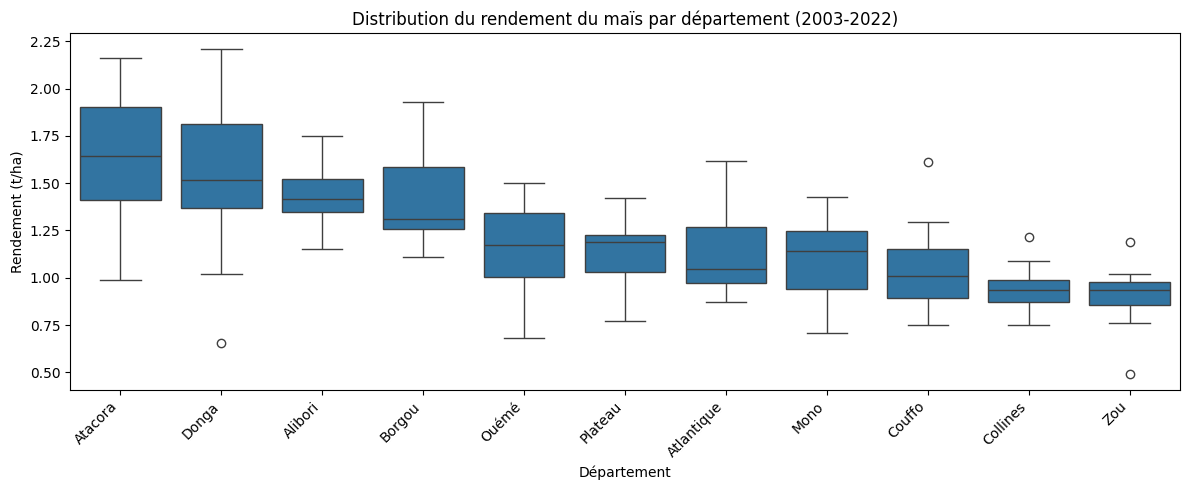

In [7]:
# Distribution du rendement par département
plt.figure(figsize=(12, 5))
ordre = dataset_final.groupby("departement")["rendement_t_ha"].mean().sort_values(ascending=False).index

sns.boxplot(data=dataset_final, x="departement", y="rendement_t_ha", order=ordre)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution du rendement du maïs par département (2003-2022)")
plt.xlabel("Département")
plt.ylabel("Rendement (t/ha)")
plt.tight_layout()
plt.savefig("../reports/figures/rendement_par_departement.png", dpi=150)
plt.show()

Atacora et Donga ont les meilleurs rendements avec une médiane autour de 1.6 t/ha
Collines et Zou ont les rendements les plus faibles autour de 0.9 t/ha
Donga a un outlier bas à 0.65 t/ha, probablement une année de stress climatique extrême

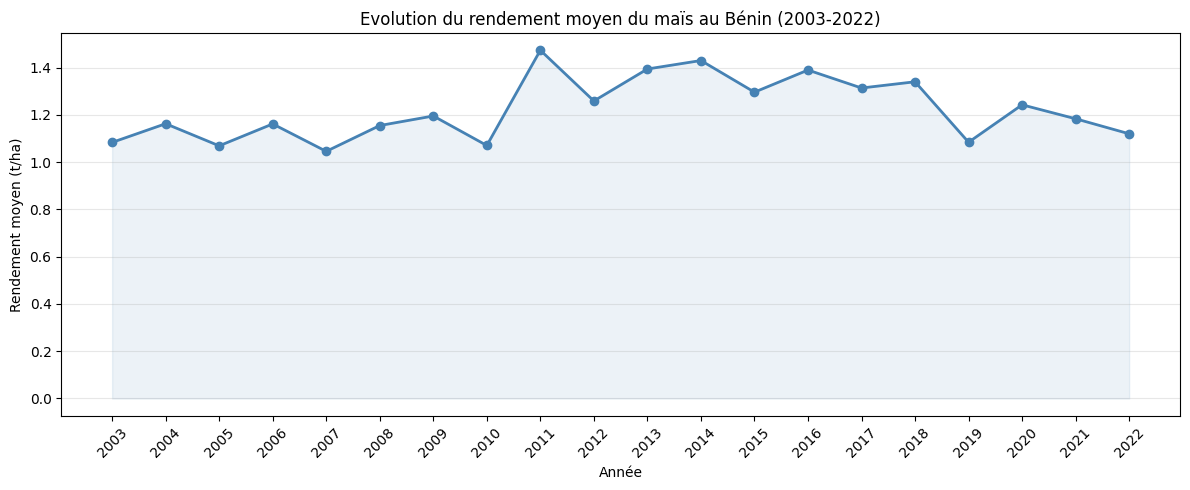

In [8]:
# Evolution du rendement moyen national par année
rendement_national = dataset_final.groupby("annee")["rendement_t_ha"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(rendement_national["annee"], rendement_national["rendement_t_ha"], 
         marker="o", linewidth=2, color="steelblue")
plt.fill_between(rendement_national["annee"], rendement_national["rendement_t_ha"], 
                 alpha=0.1, color="steelblue")
plt.title("Evolution du rendement moyen du maïs au Bénin (2003-2022)")
plt.xlabel("Année")
plt.ylabel("Rendement moyen (t/ha)")
plt.xticks(rendement_national["annee"], rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/evolution_rendement_national.png", dpi=150)
plt.show()



2011 est l'année record avec 1.47 t/ha, probablement une très bonne saison pluvieuse
2010 et 2019 sont les pires années avec environ 1.08 t/ha, années connues pour leurs anomalies climatiques au Bénin
Une légère tendance à la hausse sur la période mais avec une forte variabilité inter-annuelle

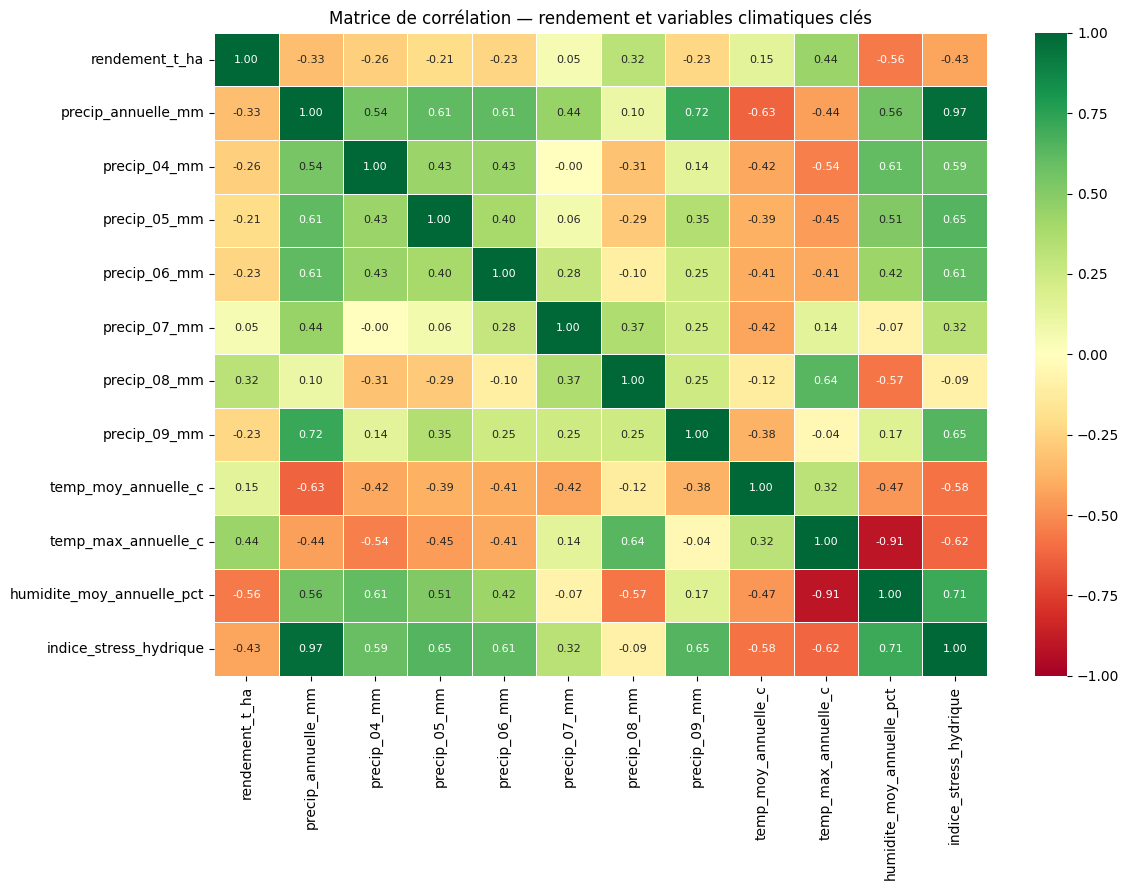

In [9]:
# Matrice de corrélation entre rendement et variables clés
cols_corr = [
    "rendement_t_ha",
    "precip_annuelle_mm", "precip_04_mm", "precip_05_mm",
    "precip_06_mm", "precip_07_mm", "precip_08_mm", "precip_09_mm",
    "temp_moy_annuelle_c", "temp_max_annuelle_c",
    "humidite_moy_annuelle_pct", "indice_stress_hydrique"
]

corr = dataset_final[cols_corr].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Matrice de corrélation — rendement et variables climatiques clés")
plt.tight_layout()
plt.savefig("../reports/figures/matrice_correlation.png", dpi=150)
plt.show()

Corrélations positives avec le rendement :

precip_08_mm : +0.32 — les pluies d'août sont bénéfiques
temp_max_annuelle_c : +0.44 — surprenant, à analyser plus loin
temp_moy_annuelle_c : +0.15 — faible

Corrélations négatives avec le rendement :

humidite_moy_annuelle_pct : -0.56 — la plus forte, les zones très humides (côtières) ont paradoxalement moins de rendement
indice_stress_hydrique : -0.43
precip_annuelle_mm : -0.33 — contre-intuitif, lié au fait que les zones les plus pluvieuses sont aussi les zones côtières à faible rendement

Ce paradoxe s'explique par un effet département : les zones du Nord (Atacora, Donga) sont plus sèches mais ont de meilleurs rendements grâce à de meilleures pratiques agricoles. 

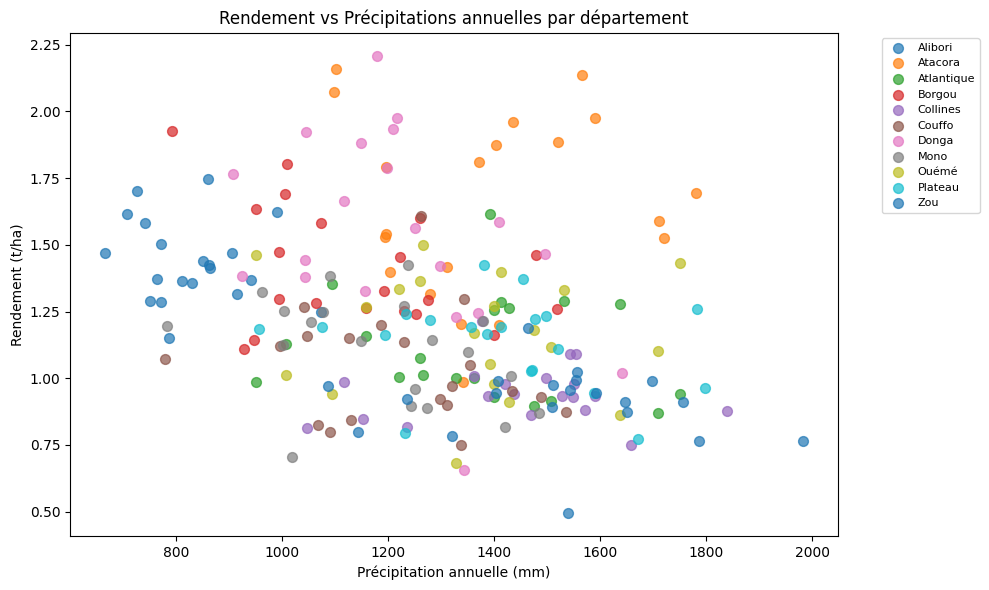

In [10]:
# Scatter plot rendement vs précipitation annuelle coloré par département
plt.figure(figsize=(10, 6))
departements_uniques = dataset_final["departement"].unique()
colors = plt.cm.tab10.colors

for i, dept in enumerate(sorted(departements_uniques)):
    subset = dataset_final[dataset_final["departement"] == dept]
    plt.scatter(subset["precip_annuelle_mm"], subset["rendement_t_ha"],
                label=dept, color=colors[i % 10], alpha=0.7, s=50)

plt.xlabel("Précipitation annuelle (mm)")
plt.ylabel("Rendement (t/ha)")
plt.title("Rendement vs Précipitations annuelles par département")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/rendement_vs_precipitation.png", dpi=150)
plt.show()

Le graphique confirme exactement ce qu'on suspectait. Les départements du Nord comme Alibori et Atacora se retrouvent à gauche (moins de pluie, 700-900mm) mais avec des rendements élevés entre 1.3 et 2.2 t/ha. Les départements côtiers comme Atlantique et Ouémé sont à droite (plus de pluie, 1400-1800mm) mais avec des rendements plus faibles.
Ce n'est donc pas la pluie seule qui explique le rendement, c'est la combinaison avec les pratiques agricoles, les types de sol et les températures.

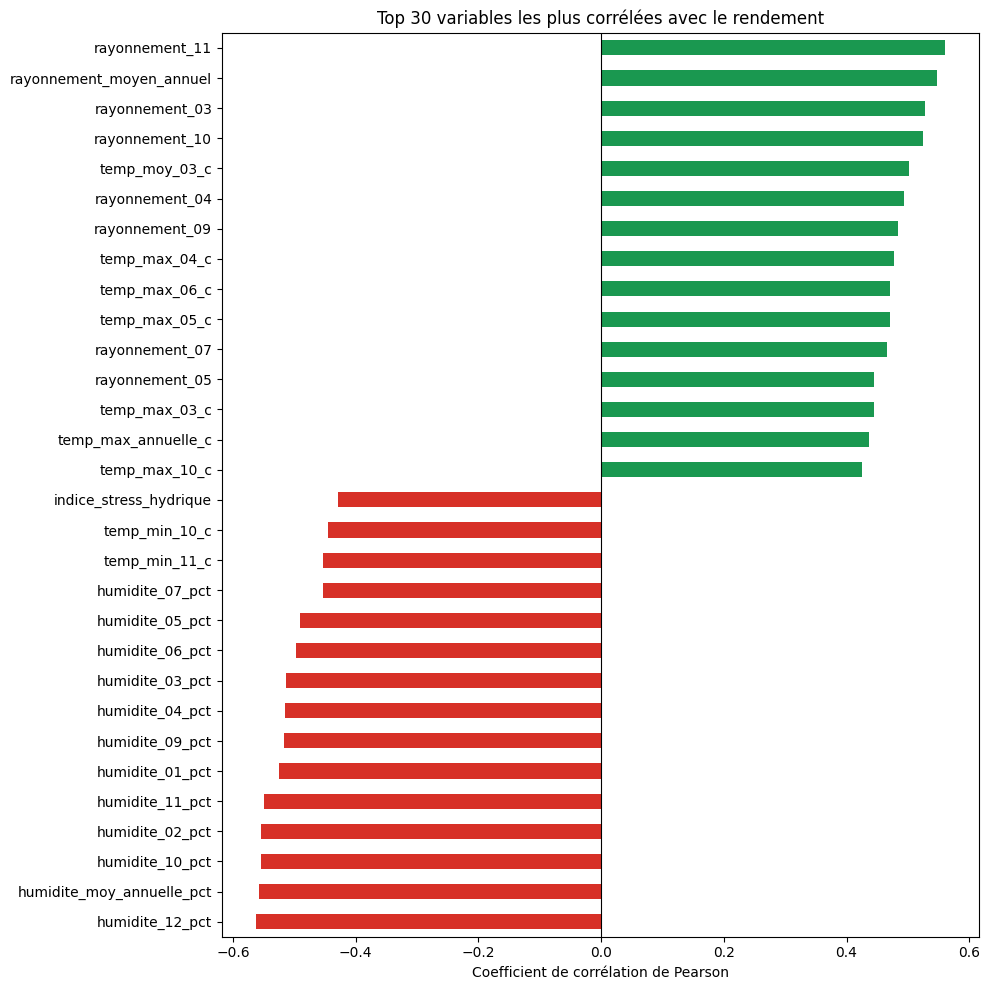

In [11]:
# Corrélation de toutes les variables avec le rendement
corr_rendement = dataset_final.drop(columns=["annee"]).select_dtypes(include="number").corr()["rendement_t_ha"].drop("rendement_t_ha").drop("rendement_kg_ha")

# Top 15 corrélations positives et négatives
top_pos = corr_rendement.nlargest(15)
top_neg = corr_rendement.nsmallest(15)
top_all = pd.concat([top_neg, top_pos]).sort_values()

plt.figure(figsize=(10, 10))
colors = ["#d73027" if v < 0 else "#1a9850" for v in top_all.values]
top_all.plot(kind="barh", color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Top 30 variables les plus corrélées avec le rendement")
plt.xlabel("Coefficient de corrélation de Pearson")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_rendement.png", dpi=150)
plt.show()

Positivement :

rayonnement_11 et rayonnement_moyen_annuel : +0.55 — le rayonnement solaire est le facteur le plus déterminant
temp_moy_03_c, temp_max_04_c etc. — les températures de début de saison

Négativement :

humidite_12_pct, humidite_moy_annuelle_pct — l'humidité élevée est associée aux zones côtières à faible rendement
indice_stress_hydrique — confirmé

Ce que ça dit concrètement : les zones à fort rayonnement solaire et températures élevées en saison sèche sont les meilleures zones maïsières, ce sont les départements du Nord.

In [12]:
# Résumé final de l'EDA
print("=== RESUME EDA ===")
print(f"\nDataset : {dataset_final.shape[0]} observations, {dataset_final.shape[1]} variables")
print(f"Période : 2003-2022")
print(f"Départements : {dataset_final['departement'].nunique()}")
print(f"\nRendement moyen national : {dataset_final['rendement_t_ha'].mean():.2f} t/ha")
print(f"Meilleur département : Atacora ({dataset_final[dataset_final['departement']=='Atacora']['rendement_t_ha'].mean():.2f} t/ha)")
print(f"Moins bon département : Zou ({dataset_final[dataset_final['departement']=='Zou']['rendement_t_ha'].mean():.2f} t/ha)")
print(f"\nVariable la plus corrélée (+) : rayonnement_11 (r=+0.55)")
print(f"Variable la plus corrélée (-) : humidite_12_pct (r=-0.59)")
print("\nFigures sauvegardées dans reports/figures/")

=== RESUME EDA ===

Dataset : 220 observations, 83 variables
Période : 2003-2022
Départements : 11

Rendement moyen national : 1.22 t/ha
Meilleur département : Atacora (1.65 t/ha)
Moins bon département : Zou (0.90 t/ha)

Variable la plus corrélée (+) : rayonnement_11 (r=+0.55)
Variable la plus corrélée (-) : humidite_12_pct (r=-0.59)

Figures sauvegardées dans reports/figures/
